In [6128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.impute import KNNImputer

In [6129]:
def report(y_true,y_pred):
    report = classification_report(y_true,y_pred)
    conf_matrix = confusion_matrix(y_true,y_pred)
    disp = ConfusionMatrixDisplay(conf_matrix)
    disp.plot()
    print(report)

In [6130]:
def model_training(list_of_models,X_train,y_train,X_test,y_test):
    for model in list_of_models:
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        print(f"Model: {model.__class__.__name__}")
        report(y_test,y_pred)


In [6131]:
df = pd.read_csv('TCA_Cleaned.csv')

In [6132]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
4,5,0,3,"Allen, Mr. William Henry",male,35.0,1,373450,8.0500,S,Mr
38,39,0,3,"Vander Planke, Miss. Augusta Maria",female,18.0,3,345764,18.0000,S,Miss
694,695,0,1,"Weir, Col. John",male,60.0,1,113800,26.5500,S,Col
171,172,0,3,"Rice, Master. Arthur",male,4.0,6,382652,29.1250,Q,Master
352,353,0,3,"Elias, Mr. Tannous",male,15.0,3,2695,7.2292,C,Mr


In [6133]:
df['Age'].isnull().sum()

np.int64(177)

In [6134]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
FamSize          0
Ticket           0
Fare             0
Embarked         2
Title            1
dtype: int64

In [6135]:
df.loc[df['Title'].isnull()]['Name'].values

array(['Rothes, the Countess. of (Lucy Noel Martha Dyer-Edwards)'],
      dtype=object)

In [6136]:
df['Title'].fillna('Other', inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_4100\3401429116.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Title'].fillna('Other', inplace=True)


In [6137]:
df.loc[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
61,62,1,1,"Icard, Miss. Amelie",female,38.0,1,113572,80.0,NaN,Miss
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,1,113572,80.0,NaN,Mrs


In [6138]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\Hp\AppData\Local\Temp\ipykernel_4100\3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [6139]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
838,839,1,3,"Chip, Mr. Chang",male,32.0,1,1601,56.4958,S,Mr
305,306,1,1,"Allison, Master. Hudson Trevor",male,1.0,4,113781,151.5500,S,Master
498,499,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,4,113781,151.5500,S,Mrs
354,355,0,3,"Yousif, Mr. Wazli",male,NaN,1,2647,7.2250,C,Mr
496,497,1,1,"Eustis, Miss. Elizabeth Mussey",female,54.0,2,36947,78.2667,C,Miss


In [6140]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
FamSize          0
Ticket           0
Fare             0
Embarked         0
Title            0
dtype: int64

## Using StandardScaler on age and Fare columns
## OneHotencoding the sex,Title and embarked columns

In [6141]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Other         1
Jonkheer      1
Name: count, dtype: int64

In [6142]:
categorical_features = ['Sex', 'Embarked', 'Title']
Sex = {'male':0,"female":1}
embarked = {'S':0,'C':1,'Q':2}
title = {'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Other':4}
def map_values(value):
    value['Sex'] = Sex[value['Sex']]
    value['Embarked'] = embarked[value['Embarked']]
    try: 
        value['Title'] = title[value['Title']]
    except KeyError: 
        if value['Title'] == 'Mme':
            value['Title'] = 2
        elif value['Title'] == 'Don' or value['Title'] == 'Jonkheer':
            value['Title'] = 3
        elif value['Title'] == 'Mlle' or value['Title'] == 'Ms':
            value['Title'] = 1
        else:
            value['Title'] = 4
    return value
df[['Sex','Embarked','Title']] = df[['Sex','Embarked','Title']].apply(map_values, axis=1)

In [6143]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
FamSize          0
Ticket           0
Fare             0
Embarked         0
Title            0
dtype: int64

In [6144]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,2,A/5 21171,7.2500,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,2,PC 17599,71.2833,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,1,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,2,113803,53.1000,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,1,373450,8.0500,0,0


In [6145]:
df['FareLog'] = np.log1p(df['Fare'])

df = df.drop(columns=['Fare'])

In [6146]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Embarked,Title,FareLog
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,2,A/5 21171,0,0,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,2,PC 17599,1,2,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,1,STON/O2. 3101282,0,1,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,2,113803,0,2,3.990834
4,5,0,3,"Allen, Mr. William Henry",0,35.0,1,373450,0,0,2.202765
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,1,211536,0,4,2.639057
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,1,112053,0,1,3.433987
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,4,W./C. 6607,0,1,3.196630
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,1,111369,1,0,3.433987


In [6147]:
scaler = StandardScaler()
numerical_features = ['Age']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [6148]:
knn_imputer = KNNImputer(n_neighbors=5)
df['Age'] = knn_imputer.fit_transform(df[['Age', 'FamSize', 'FareLog','Title']])

In [6149]:
xgbModel = xgbModel = XGBClassifier(random_state=42,n_estimators=100,max_depth=3,reg_lambda=2.0,reg_alpha=1.0,min_child_weight=3,gamma=0.1
)
RFModel = RandomForestClassifier(random_state=42,n_estimators=100,max_depth=3,min_samples_split=5,min_samples_leaf=4)
list_of_models = [xgbModel,RFModel]
x = df.drop(columns=['Survived','Name','Ticket','PassengerId'], axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

In [6150]:
X_train

,Pclass,Sex,Age,FamSize,Embarked,Title,FareLog
331,1,0,1.123490,1,0,0,3.384390
733,2,0,-0.461149,1,0,0,2.639057
382,3,0,0.158927,1,0,0,2.188856
704,3,0,-0.254457,2,0,0,2.180892
813,3,1,-1.632403,7,0,1,3.474293
...,...,...,...,...,...,...,...
106,3,1,-0.598944,1,0,1,2.157559
270,1,0,1.509315,1,0,0,3.465736
860,3,0,0.779003,3,0,0,2.715244
435,1,1,-1.081225,4,0,1,4.795791


In [6151]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((712, 7), (712,), (179, 7), (179,))

In [6152]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'FamSize', 'Embarked', 'Title', 'FareLog'], dtype='object')

Model: XGBClassifier
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.77      0.80        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



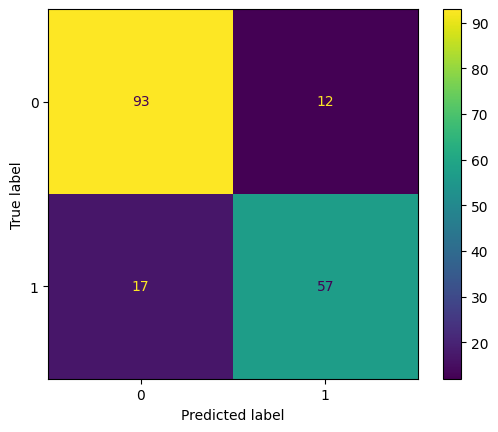

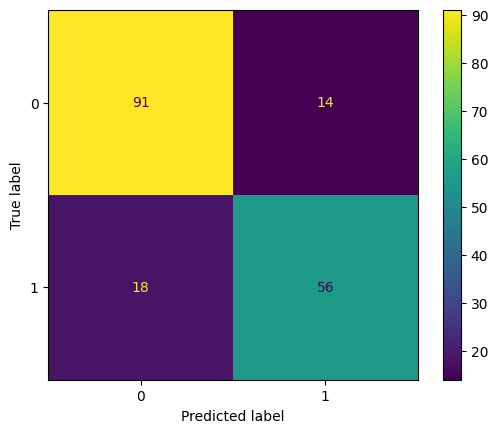

In [6153]:
model_training(list_of_models,X_train,y_train,X_test,y_test)

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       444
           1       0.92      0.77      0.84       268

    accuracy                           0.89       712
   macro avg       0.89      0.86      0.87       712
weighted avg       0.89      0.89      0.88       712



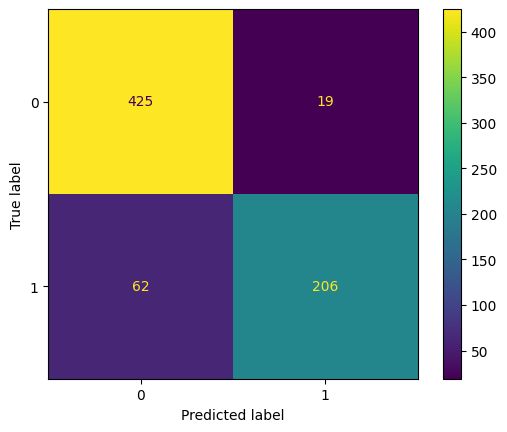

In [6154]:
report(y_train,xgbModel.predict(X_train))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87       444
           1       0.81      0.73      0.77       268

    accuracy                           0.83       712
   macro avg       0.83      0.81      0.82       712
weighted avg       0.83      0.83      0.83       712



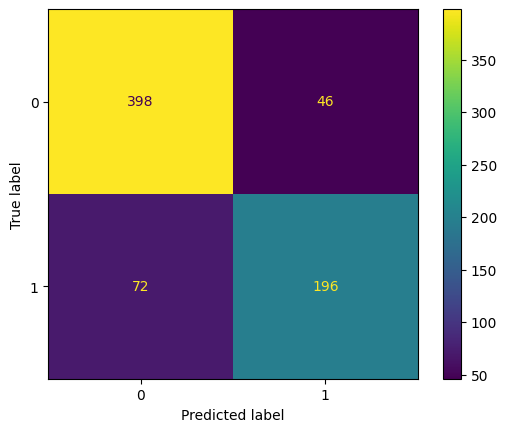

In [6155]:
report(y_train,RFModel.predict(X_train))

In [6156]:
xgbFI = xgbModel.feature_importances_
RFFI = RFModel.feature_importances_

In [6157]:
columns = X_train.columns

Text(0.5, 1.0, 'RF Feature Importance')

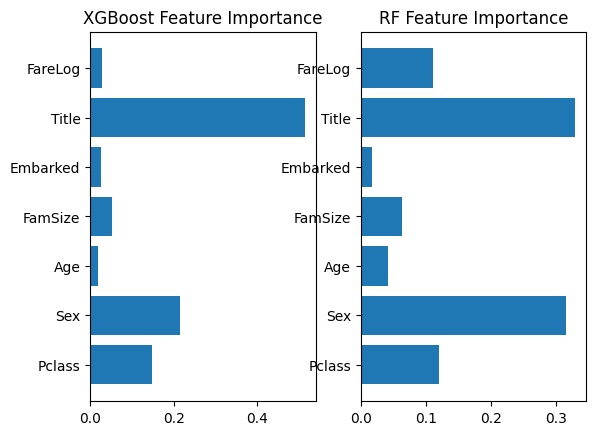

In [6158]:
ax = plt.subplot(1,2,1)
ax.barh(columns,xgbFI)
ax.set_title("XGBoost Feature Importance")
ax = plt.subplot(1,2,2)
ax.barh(columns,RFFI)
ax.set_title("RF Feature Importance")

In [6159]:
X_train = df.drop(columns=['Survived','Name','Ticket','PassengerId'], axis=1)
y_train = df['Survived']

In [6160]:
X_train

,Pclass,Sex,Age,FamSize,Embarked,Title,FareLog
0,3,0,-0.530046,2,0,0,2.110213
1,1,1,0.572311,2,1,2,4.280593
2,3,1,-0.254457,1,0,1,2.188856
3,1,1,0.365619,2,0,2,3.990834
4,3,0,0.365619,1,0,0,2.202765
...,...,...,...,...,...,...,...
886,2,0,-0.185560,1,0,4,2.639057
887,1,1,-0.736738,1,0,1,3.433987
888,3,1,-1.825316,4,0,1,3.196630
889,1,0,-0.254457,1,1,0,3.433987


In [6161]:
X_train

,Pclass,Sex,Age,FamSize,Embarked,Title,FareLog
0,3,0,-0.530046,2,0,0,2.110213
1,1,1,0.572311,2,1,2,4.280593
2,3,1,-0.254457,1,0,1,2.188856
3,1,1,0.365619,2,0,2,3.990834
4,3,0,0.365619,1,0,0,2.202765
...,...,...,...,...,...,...,...
886,2,0,-0.185560,1,0,4,2.639057
887,1,1,-0.736738,1,0,1,3.433987
888,3,1,-1.825316,4,0,1,3.196630
889,1,0,-0.254457,1,1,0,3.433987


              precision    recall  f1-score   support

           0       0.90      0.91      0.91       105
           1       0.88      0.85      0.86        74

    accuracy                           0.89       179
   macro avg       0.89      0.88      0.88       179
weighted avg       0.89      0.89      0.89       179



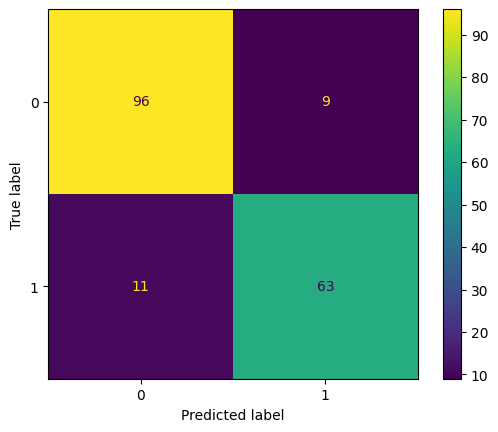

In [6162]:
model = XGBClassifier(random_state=42,n_estimators=100,max_depth=3,reg_lambda=2.0,reg_alpha=1.0,min_child_weight=3,gamma=0.1
)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
report(y_test,y_pred)

Text(0.5, 1.0, 'XGBoost Feature Importance')

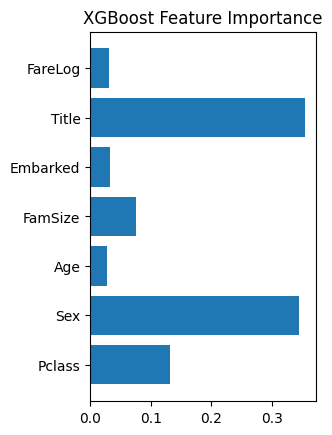

In [6163]:
final_model_FI = model.feature_importances_
ax = plt.subplot(1,2,1)
ax.barh(columns,final_model_FI)
ax.set_title("XGBoost Feature Importance")

In [6164]:
test_data = pd.read_csv('test.csv')

In [6165]:
test_data.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
203,1095,2,"Quick, Miss. Winifred Vera",female,8.0,1,1,26360,26.0000,NaN,S
273,1165,3,"Lennon, Miss. Mary",female,NaN,1,0,370371,15.5000,NaN,Q
150,1042,1,"Earnshaw, Mrs. Boulton (Olive Potter)",female,23.0,0,1,11767,83.1583,C54,C
140,1032,3,"Goodwin, Miss. Jessie Allis",female,10.0,5,2,CA 2144,46.9000,NaN,S
21,913,3,"Olsen, Master. Artur Karl",male,9.0,0,1,C 17368,3.1708,NaN,S


In [6166]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

In [6167]:
test_data.drop('Cabin',axis=1,inplace=True)

In [6168]:
test_data.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        0
dtype: int64

In [6169]:
test_data["FamSize"] = test_data["SibSp"] + test_data["Parch"] + 1
test_data.drop(columns=['SibSp','Parch','Ticket'],inplace=True)
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize
155,1047,3,"Duquemin, Mr. Joseph",male,24.0,7.55,S,1
107,999,3,"Ryan, Mr. Edward",male,NaN,7.75,Q,1


In [6170]:
test_data["Title"] = test_data["Name"].str.extract(r", (\w+)\.")

In [6171]:
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize,Title
387,1279,2,"Ashby, Mr. John",male,57.0,13.0,S,1,Mr
131,1023,1,"Gracie, Col. Archibald IV",male,53.0,28.5,C,1,Col


In [6172]:
test_data['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [6173]:
test_data[['Sex','Embarked','Title']] = test_data[['Sex','Embarked','Title']].apply(map_values, axis=1)
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize,Title
346,1238,2,"Botsford, Mr. William Hull",0,26.0,13.0,0,1,0
308,1200,1,"Hays, Mr. Charles Melville",0,55.0,93.5,0,3,0


In [6174]:
test_data['FareLog'] = np.log1p(test_data['Fare'])

In [6175]:
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize,Title,FareLog
97,989,3,"Makinen, Mr. Kalle Edvard",0,29.0,7.9250,0,1,0,2.188856
404,1296,1,"Frauenthal, Mr. Isaac Gerald",0,43.0,27.7208,1,2,0,3.357622


In [6176]:
test_data['Age'] = scaler.transform(test_data[['Age']])

In [6177]:
test_data['Age'] = knn_imputer.transform(test_data[['Age', 'FamSize', 'FareLog','Title']])

In [6178]:
test_data.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
Fare           0
Embarked       0
FamSize        0
Title          0
FareLog        0
dtype: int64

In [6179]:
X_data = test_data[X_train.columns]

In [6180]:
X_data

,Pclass,Sex,Age,FamSize,Embarked,Title,FareLog
0,3,0,0.331170,1,2,0,2.178064
1,3,1,1.192387,2,0,2,2.079442
2,2,0,2.225847,1,2,0,2.369075
3,3,0,-0.185560,1,0,0,2.268252
4,3,1,-0.530046,3,0,2,2.586824
...,...,...,...,...,...,...,...
413,3,0,-0.226898,1,0,0,2.202765
414,1,1,0.641208,1,1,4,4.699571
415,3,0,0.606760,1,0,0,2.110213
416,3,0,-0.226898,1,0,0,2.202765


In [6181]:
y_pred = model.predict(X_data)

In [6182]:
final_submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': y_pred
})

In [6183]:
final_submission.to_csv('Submission.csv',index=False)